In [10]:
# Step 1: Import required libraries and modules
import sys, os
sys.path.append(os.path.abspath("..")) 

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from preprocessing.dataset import SignLanguageDataset

In [18]:
import torch
print("CUDA available:", torch.cuda.is_available())

CUDA available: False


In [11]:
# Step 2: Define image transforms and label mapping 

train_transform = A.Compose([
    A.Resize(128, 128),  
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), 
    ToTensorV2()
])

train_root = "../data/frames/train"

# Obtain the category list and establish the tag mapping.
class_names = sorted([
    d for d in os.listdir(train_root)
    if os.path.isdir(os.path.join(train_root, d)) and not d.startswith(".")
])
label_map = {name: idx for idx, name in enumerate(class_names)}

print("Discovered classes:", label_map)

Discovered classes: {'accident': 0, 'africa': 1, 'all': 2, 'apple': 3, 'basketball': 4, 'bed': 5, 'before': 6, 'bird': 7, 'birthday': 8, 'black': 9, 'blue': 10, 'book': 11, 'bowling': 12, 'brown': 13, 'but': 14, 'can': 15, 'candy': 16, 'chair': 17, 'change': 18, 'cheat': 19, 'city': 20, 'clothes': 21, 'color': 22, 'computer': 23, 'cook': 24, 'cool': 25, 'corn': 26, 'cousin': 27, 'cow': 28, 'dance': 29, 'dark': 30, 'deaf': 31, 'decide': 32, 'doctor': 33, 'dog': 34, 'drink': 35, 'eat': 36, 'enjoy': 37, 'family': 38, 'fine': 39, 'finish': 40, 'fish': 41, 'forget': 42, 'full': 43, 'give': 44, 'go': 45, 'graduate': 46, 'hat': 47, 'hearing': 48, 'help': 49, 'hot': 50, 'how': 51, 'jacket': 52, 'kiss': 53, 'language': 54, 'last': 55, 'later': 56, 'letter': 57, 'like': 58, 'man': 59, 'many': 60, 'medicine': 61, 'meet': 62, 'mother': 63, 'need': 64, 'no': 65, 'now': 66, 'orange': 67, 'paint': 68, 'paper': 69, 'pink': 70, 'pizza': 71, 'play': 72, 'pull': 73, 'purple': 74, 'right': 75, 'same': 76,

In [12]:
# Step 3: Build dataset and dataloader
train_dataset = SignLanguageDataset(
    root_dir=train_root,
    label_map=label_map,
    transform=train_transform
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)


[DEBUG] First 5 samples loaded:
Sample 0: class=apple, label=3
    Frame count: 16 | First frame: ../data/frames/train/apple/68003/frame_000.jpg
Sample 1: class=apple, label=3
    Frame count: 16 | First frame: ../data/frames/train/apple/65084/frame_000.jpg
Sample 2: class=apple, label=3
    Frame count: 16 | First frame: ../data/frames/train/apple/70309/frame_000.jpg
Sample 3: class=apple, label=3
    Frame count: 16 | First frame: ../data/frames/train/apple/03003/frame_000.jpg
Sample 4: class=apple, label=3
    Frame count: 16 | First frame: ../data/frames/train/apple/65085/frame_000.jpg


In [13]:
# Step 4: Define MobileNetV3-only classifier

from models.mobilenetv3 import MobileNetV3Extractor

class MobileNetV3Classifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.feature_extractor = MobileNetV3Extractor()
        self.fc = nn.Linear(960, num_classes)

    def forward(self, x):  # x: [B, T, C, H, W] or [B, C, H, W]
        if x.dim() == 5:
            # Take only the first frame, or average pool all frames.
            x = x[:, 0, :, :, :]  # [B, C, H, W]
        features = self.feature_extractor(x)  # [B, 960]
        logits = self.fc(features)            # [B, num_classes]
        return logits

In [14]:
# Step 5: Set device, initialize model, loss function, optimizer 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MobileNetV3Classifier(num_classes=len(label_map)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

In [15]:
# Step 6: Setup validation dataloader

val_root = "../data/frames/validation"  

val_transform = A.Compose([
    A.Resize(128, 128),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_dataset = SignLanguageDataset(
    root_dir=val_root,
    label_map=label_map,
    transform=val_transform
)

val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)


[DEBUG] First 5 samples loaded:
Sample 0: class=apple, label=3
    Frame count: 16 | First frame: ../data/frames/validation/apple/69213/frame_000.jpg
Sample 1: class=apple, label=3
    Frame count: 16 | First frame: ../data/frames/validation/apple/02999/frame_000.jpg
Sample 2: class=apple, label=3
    Frame count: 16 | First frame: ../data/frames/validation/apple/65086/frame_000.jpg
Sample 3: class=accident, label=0
    Frame count: 16 | First frame: ../data/frames/validation/accident/00626/frame_000.jpg
Sample 4: class=accident, label=0
    Frame count: 16 | First frame: ../data/frames/validation/accident/00627/frame_000.jpg


In [19]:
# Step 7: Training and validation loop

from torch.cuda.amp import autocast, GradScaler


# Check if there is a saved model to enable continued training.
start_epoch = 0
if os.path.exists('mobilenetv3_baseline_best.pth'):
    model.load_state_dict(torch.load('mobilenetv3_baseline_best.pth'))
    print("Loaded existing mobilenetv3_baseline model, continuing training...")
    start_epoch = 10 
else:
    print("Starting mobilenetv3_baseline training from scratch...")

scaler = GradScaler()
num_epochs = 15
train_loss_list, val_loss_list = [], []
train_acc_list, val_acc_list = [], []
best_val_acc = 0.0

def evaluate(model, val_loader, criterion):
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for videos, labels in val_loader:
            videos, labels = videos.to(device), labels.to(device)
            outputs = model(videos)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    avg_loss = val_loss / len(val_loader)
    accuracy = correct / total
    return avg_loss, accuracy

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0
    loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}(Actual: {epoch+1})')
    for batch_idx, (videos, labels) in enumerate(loop):
        videos = videos.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        with autocast():
            outputs = model(videos)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        train_loss += loss.item()
        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)
    train_loss = train_loss / len(train_loader)
    train_acc = 100. * correct / total
    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc*100)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'mobilenetv3_baseline_best.pth')
        print(f'New best model saved with val_acc: {val_acc:.2f}')
    print(f'Epoch: {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%')

Loaded existing mobilenetv3_baseline model, continuing training...


Epoch 1/15: 100%|██████████| 251/251 [04:01<00:00,  1.04it/s, acc=33.4, loss=4.58]


New best model saved with val_acc: 0.07
Epoch: 1/15 | Train Loss: 2.9875 | Train Acc: 33.37% | Val Loss: 5.0115 | Val Acc: 6.61%


Epoch 2/15: 100%|██████████| 251/251 [03:24<00:00,  1.23it/s, acc=40.8, loss=4.3] 


New best model saved with val_acc: 0.07
Epoch: 2/15 | Train Loss: 2.7131 | Train Acc: 40.76% | Val Loss: 5.0484 | Val Acc: 7.44%


...

Epoch: 13/15 | Train Loss: 0.7792 | Train Acc: 87.21% | Val Loss: 6.3327 | Val Acc: 12.81%


Epoch 14/15: 100%|██████████| 251/251 [02:43<00:00,  1.54it/s, acc=90.2, loss=4.29] 


New best model saved with val_acc: 0.15
Epoch: 14/15 | Train Loss: 0.6646 | Train Acc: 90.21% | Val Loss: 6.5569 | Val Acc: 15.29%


Epoch 15/15: 100%|██████████| 251/251 [03:18<00:00,  1.26it/s, acc=91.4, loss=3.75]  


Epoch: 15/15 | Train Loss: 0.5932 | Train Acc: 91.41% | Val Loss: 7.1014 | Val Acc: 12.81%


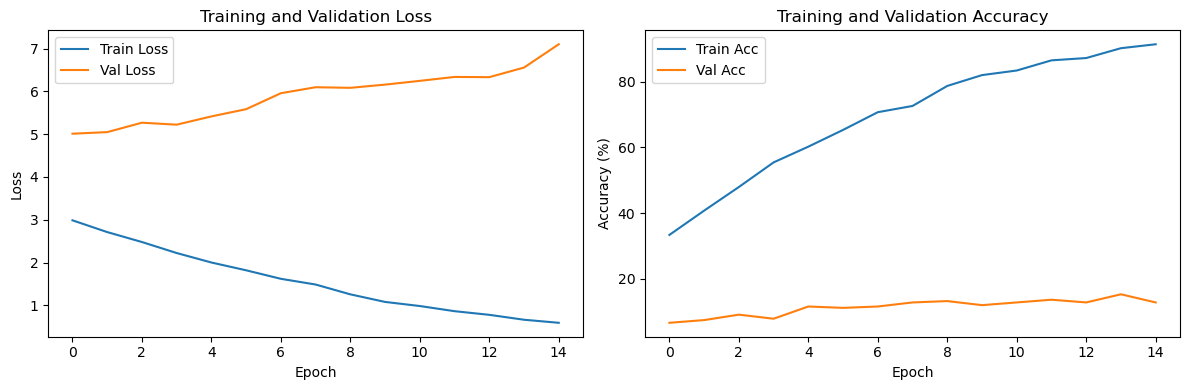

Best Validation Accuracy: 15.29%


In [20]:
# Step 8: Plot training and validation curves

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_list, label='Train Acc')
plt.plot(val_acc_list, label='Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()
print(f'Best Validation Accuracy: {best_val_acc*100:.2f}%')